In [ ]:
# Importar las librerias necesarias
import os                                                                           # Funcionalidades para interactuar con el sistema operativo
import sklearn                                                                      # Biblioteca principal de machine learning en Python
import numpy as np                                                                  # Manipulación numérica eficiente de matrices y vectores
import pandas as pd                                                                 # Estructuras de datos y herramientas para análisis de datos
import seaborn as sns                                                               # Biblioteca para visualización de datos basada en matplotlib
from scipy import stats                                                             # Funciones estadísticas y matemáticas avanzadas
from sklearn import tree                                                            # Algoritmos de árboles de decisión para clasificación/regresión
from sklearn import metrics                                                         # Métricas de evaluación para modelos de machine learning
from sklearn import datasets                                                        # Conjuntos de datos de ejemplo
import statsmodels.api as sm                                                        # Modelos estadísticos y análisis de datos
from google.colab import files                                                      # Interacción con archivos en Google Colab (entorno de notebooks)
import matplotlib.pyplot as plt                                                     # Biblioteca para trazar gráficos
from imblearn.over_sampling import SMOTE                                            # Técnica de aumento de datos para abordar desequilibrio de clases
from sklearn.tree import DecisionTreeClassifier                                     # Clasificador de árbol de decisión
from sklearn.datasets import load_breast_cancer                                     # Conjunto de datos de cáncer de mama
from sklearn.datasets import make_classification                                    # Generación de datos sintéticos para clasificación
from sklearn.model_selection import StratifiedKFold                                 #
from imblearn.over_sampling import RandomOverSampler                                # Técnica de aumento de datos para equilibrar clases
from sklearn.model_selection import train_test_split, GridSearchCV                  # División de datos y búsqueda de hiperparámetros
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz
import matplotlib.pyplot as plt

In [ ]:
# Seleccionar y cargar un archivo desde tu computadora
uploaded = files.upload()

# Obtener el nombre del archivo cargado
file_name = list(uploaded.keys())[0]

# Realizar operaciones con el archivo cargado
# ...

# Eliminar el archivo cargado (opcional)
# files.remove(file_name)

Saving data_bank.csv to data_bank.csv


In [ ]:
data = pd.read_csv('data_bank.csv', sep=';') # Crear el DataSet con el csv proporcionado

In [ ]:
data.head() # Ver la composicion de los datos

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
data.shape # Ver las dimenciones de la data

(41188, 21)

In [ ]:
bank_data = data[['age', 'default', 'cons.price.idx', 'cons.conf.idx', 'y']]
bank_data.head()

,age,default,cons.price.idx,cons.conf.idx,y
0,56,no,93.994,-36.4,no
1,57,unknown,93.994,-36.4,no
2,37,no,93.994,-36.4,no
3,40,no,93.994,-36.4,no
4,56,no,93.994,-36.4,no


In [ ]:
bank_data['default'] = bank_data['default'].map({'no':0,'yes':1,'unknown':0})
bank_data['y'] = bank_data['y'].map({'no':0,'yes':1})

<ipython-input-15-def75a7de8a6>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_data['default'] = bank_data['default'].map({'no':0,'yes':1,'unknown':0})
<ipython-input-15-def75a7de8a6>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bank_data['y'] = bank_data['y'].map({'no':0,'yes':1})


In [ ]:
X = bank_data.drop('y', axis=1)
y = bank_data['y']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=6)

In [ ]:
rf = RandomForestClassifier()

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
y_pred = rf.predict(X_test)

In [ ]:
pred = pd.crosstab(y_test, y_pred)
pred

col_0,0,1
y,,
0,7116,218
1,704,200


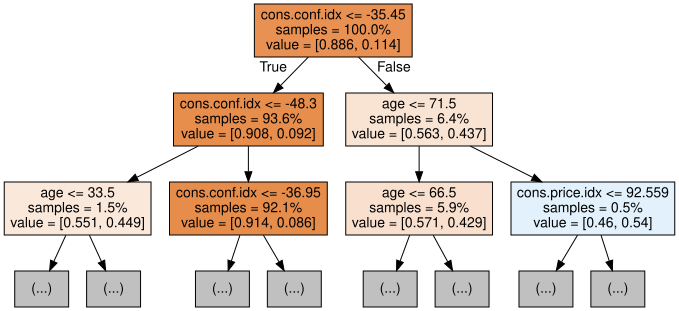

In [ ]:
for i in range(1):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,
                               filled=True,
                               max_depth=2,
                               impurity=False,
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

In [ ]:
param_dist = {'n_estimators': randint(50,500),
              'max_depth': randint(1,20)}

# Create a random forest classifier
rf = RandomForestClassifier()

# Use random search to find the best hyperparameters
rand_search = RandomizedSearchCV(rf,
                                 param_distributions = param_dist,
                                 n_iter=5,
                                 cv=5)

# Fit the random search object to the data
rand_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79aa62c68f10>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x79aa62c6a680>})

In [ ]:
best_rf = rand_search.best_estimator_

# Print the best hyperparameters
print('Best hyperparameters:',  rand_search.best_params_)

Best hyperparameters: {'max_depth': 4, 'n_estimators': 424}


In [ ]:
feature_importances = pd.Series(best_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_importances

cons.conf.idx     0.551002
cons.price.idx    0.294575
age               0.154424
default           0.000000
dtype: float64

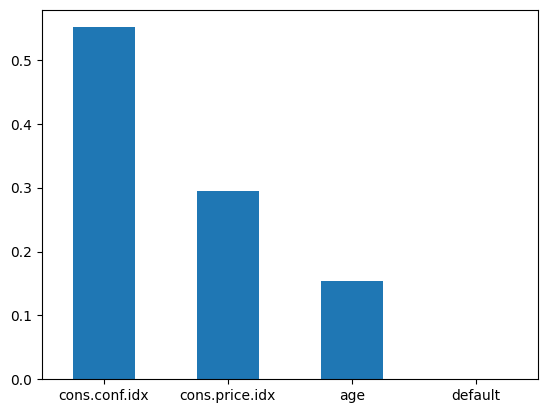

In [ ]:
feature_importances.plot.bar();
plt.xticks(rotation=0)
plt.show()